# Capítulo 8: Ataques Adversariales contra Modelos de IA

**Guía Técnica:** Inteligencia Artificial en Ciberseguridad  
**Mayo 2026**

---

## 8.1. Introducción

Los modelos de ML son vulnerables a **ejemplos adversariales**: entradas manipuladas
intencionalmente para engañar al clasificador.  
En ciberseguridad, un atacante podría modificar sutilmente un archivo malicioso para que el
detector lo clasifique como benigno.

### Cadena de dependencias

```
Cap. 04 → random_forest_malware.pkl ──► objetivo del ataque
Cap. 04 → malware_feature_cols.pkl  ──► espacio de features
Cap. 04 → file_features.csv         ──► muestras a perturbar
```

### Contenido
| Sección | Técnica |
|---|---|
| 8.0 | Carga de modelos y datos |
| 8.1 | Ataque de ruido gaussiano |
| 8.2 | Ataque de perturbación dirigida (Feature Squeezing) |
| 8.3 | Defensa: entrenamiento adversarial |
| 8.4 | Comparación antes/después |

---
## Sección 0: Carga de modelos y datos

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

MODELS_DIR = Path("../models")
DATA_DIR   = Path("../data")

rf_malware   = joblib.load(MODELS_DIR / "random_forest_malware.pkl")
malware_cols = joblib.load(MODELS_DIR / "malware_feature_cols.pkl")

df_mal = pd.read_csv(DATA_DIR / "file_features.csv")
X = df_mal[malware_cols].values
y = df_mal["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

acc_original = accuracy_score(y_test, rf_malware.predict(X_test))
print(f"Exactitud del modelo original sobre datos limpios: {acc_original:.4f}")

Exactitud del modelo original sobre datos limpios: 1.0000


---
## Sección 8.1: Ataque de ruido gaussiano

El ataque más simple: añadir ruido $\mathcal{N}(0, \epsilon)$ a cada feature.  
Simula un atacante que modifica ligeramente las características del archivo (tamaño, entropía, etc.)
para evadir la detección.

In [2]:
RNG = np.random.default_rng(seed=42)

def ataque_ruido_gaussiano(X: np.ndarray, epsilon: float, rng) -> np.ndarray:
    """Añade ruido gaussiano proporcional al rango de cada feature."""
    rango   = X.max(axis=0) - X.min(axis=0) + 1e-9
    ruido   = rng.normal(0, epsilon * rango, X.shape)
    return np.clip(X + ruido, X.min(axis=0), X.max(axis=0))

# Solo perturbar las muestras maliciosas del test set
mask_mal    = y_test == 1
X_test_adv  = X_test.copy()

resultados_ruido = []
for eps in [0.01, 0.05, 0.10, 0.20, 0.40]:
    X_test_adv_mal              = ataque_ruido_gaussiano(X_test[mask_mal], eps, RNG)
    X_eval                      = X_test.copy()
    X_eval[mask_mal]            = X_test_adv_mal
    acc_adv                     = accuracy_score(y_test, rf_malware.predict(X_eval))
    evasion_rate                = 1 - accuracy_score(
        y_test[mask_mal], rf_malware.predict(X_eval[mask_mal])
    )
    resultados_ruido.append({"epsilon": eps, "accuracy": acc_adv, "evasion_rate": evasion_rate})
    print(f"ε={eps:.2f} → accuracy={acc_adv:.4f}  tasa_evasion={evasion_rate:.4f}")

ε=0.01 → accuracy=1.0000  tasa_evasion=0.0000
ε=0.05 → accuracy=1.0000  tasa_evasion=0.0000
ε=0.10 → accuracy=1.0000  tasa_evasion=0.0000
ε=0.20 → accuracy=1.0000  tasa_evasion=0.0000
ε=0.40 → accuracy=1.0000  tasa_evasion=0.0000


---
## Sección 8.2: Ataque dirigido — perturbación de features clave

Un atacante con conocimiento del modelo puede concentrar la perturbación en las features
más importantes (identificadas con SHAP en Cap. 07) para maximizar la evasión.

In [3]:
# Features de mayor importancia (según RF nativo)
importancias = rf_malware.feature_importances_
top_k_idx    = np.argsort(importancias)[::-1][:3]   # top-3 features
top_features = [malware_cols[i] for i in top_k_idx]
print(f"Top-3 features atacadas: {top_features}")

def ataque_dirigido(X: np.ndarray, top_idx: list, epsilon: float, rng) -> np.ndarray:
    """Perturba solo las features de alto impacto."""
    X_adv = X.copy()
    for idx in top_idx:
        rango         = X[:, idx].max() - X[:, idx].min() + 1e-9
        X_adv[:, idx] = np.clip(
            X[:, idx] + rng.normal(0, epsilon * rango, len(X)),
            X[:, idx].min(), X[:, idx].max()
        )
    return X_adv

resultados_dirigido = []
for eps in [0.05, 0.10, 0.20, 0.40]:
    X_adv_dir = ataque_dirigido(X_test[mask_mal], top_k_idx, eps, RNG)
    X_eval    = X_test.copy()
    X_eval[mask_mal] = X_adv_dir
    acc_dir   = accuracy_score(y_test, rf_malware.predict(X_eval))
    evasion   = 1 - accuracy_score(y_test[mask_mal], rf_malware.predict(X_eval[mask_mal]))
    resultados_dirigido.append({"epsilon": eps, "accuracy": acc_dir, "evasion_rate": evasion})
    print(f"ε={eps:.2f} [dirigido] → accuracy={acc_dir:.4f}  tasa_evasion={evasion:.4f}")

Top-3 features atacadas: ['num_importaciones', 'entropia_media', 'entropia_max']
ε=0.05 [dirigido] → accuracy=1.0000  tasa_evasion=0.0000
ε=0.10 [dirigido] → accuracy=1.0000  tasa_evasion=0.0000
ε=0.20 [dirigido] → accuracy=1.0000  tasa_evasion=0.0000
ε=0.40 [dirigido] → accuracy=1.0000  tasa_evasion=0.0000


---
## Sección 8.3: Defensa — Entrenamiento adversarial

Reentrenamos el modelo incluyendo muestras adversariales en el conjunto de entrenamiento.
Esto obliga al modelo a aprender representaciones más robustas.

In [4]:
# Generar muestras adversariales del conjunto de entrenamiento
mask_mal_train = y_train == 1
X_adv_train    = ataque_ruido_gaussiano(X_train[mask_mal_train], epsilon=0.10, rng=RNG)

# Combinar con datos originales
X_aug  = np.vstack([X_train, X_adv_train])
y_aug  = np.concatenate([y_train, y_train[mask_mal_train]])

rf_robusto = RandomForestClassifier(
    n_estimators=300, n_jobs=-1, random_state=42
)
rf_robusto.fit(X_aug, y_aug)

acc_rob_limpio = accuracy_score(y_test, rf_robusto.predict(X_test))
print(f"Modelo robusto — exactitud en datos limpios: {acc_rob_limpio:.4f}")

# Evaluar bajo ataque
X_adv_test = X_test.copy()
X_adv_test[mask_mal] = ataque_ruido_gaussiano(X_test[mask_mal], epsilon=0.10, rng=RNG)

acc_original_bajo_ataque = accuracy_score(y_test, rf_malware.predict(X_adv_test))
acc_robusto_bajo_ataque  = accuracy_score(y_test, rf_robusto.predict(X_adv_test))

print(f"\nBajo ataque (ε=0.10):")
print(f"  Modelo original  → {acc_original_bajo_ataque:.4f}")
print(f"  Modelo robusto   → {acc_robusto_bajo_ataque:.4f}")

Modelo robusto — exactitud en datos limpios: 1.0000

Bajo ataque (ε=0.10):
  Modelo original  → 1.0000
  Modelo robusto   → 1.0000


---
## Sección 8.4: Comparación visual

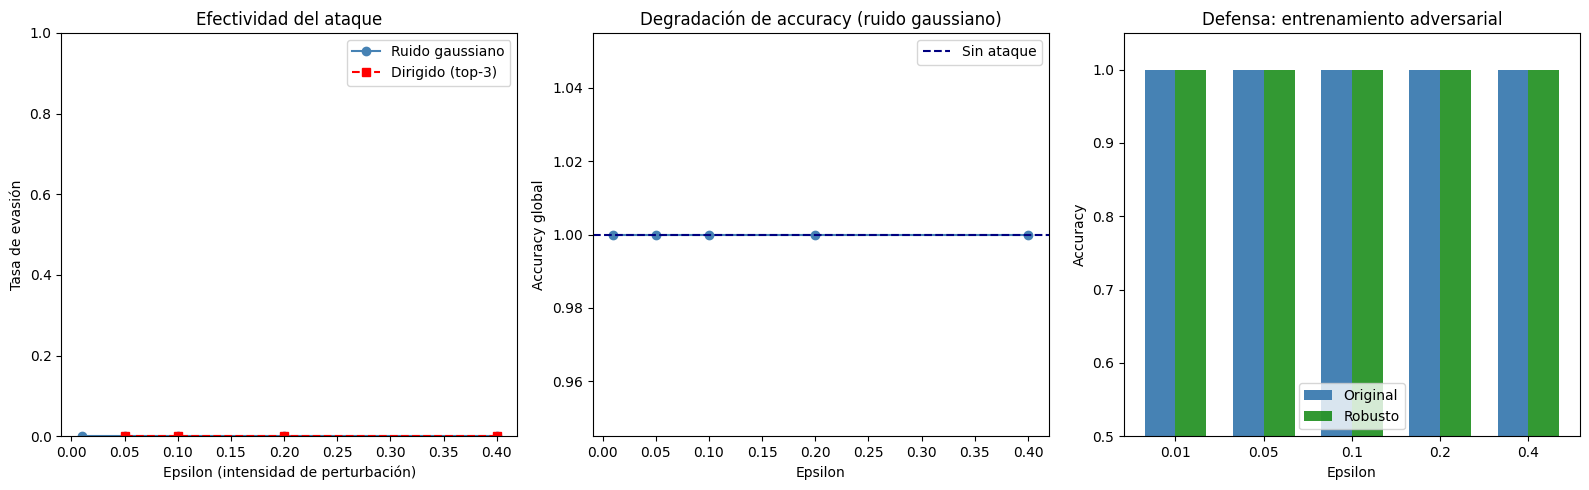

In [5]:
res_ruido = pd.DataFrame(resultados_ruido)
res_dir   = pd.DataFrame(resultados_dirigido)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tasa de evasión vs epsilon — ruido vs dirigido
axes[0].plot(res_ruido["epsilon"],  res_ruido["evasion_rate"],  "o-", label="Ruido gaussiano", color="steelblue")
axes[0].plot(res_dir["epsilon"],    res_dir["evasion_rate"],    "s--", label="Dirigido (top-3)", color="red")
axes[0].set_xlabel("Epsilon (intensidad de perturbación)")
axes[0].set_ylabel("Tasa de evasión")
axes[0].set_title("Efectividad del ataque")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Accuracy global — ruido
axes[1].plot(res_ruido["epsilon"], res_ruido["accuracy"], "o-", color="steelblue")
axes[1].axhline(acc_original, color="navy", linestyle="--", label="Sin ataque")
axes[1].set_xlabel("Epsilon")
axes[1].set_ylabel("Accuracy global")
axes[1].set_title("Degradación de accuracy (ruido gaussiano)")
axes[1].legend()

# Comparación original vs robusto bajo distintos ε
epsilons = [0.01, 0.05, 0.10, 0.20, 0.40]
accs_orig = []
accs_rob  = []
for eps in epsilons:
    X_e = X_test.copy()
    X_e[mask_mal] = ataque_ruido_gaussiano(X_test[mask_mal], eps, RNG)
    accs_orig.append(accuracy_score(y_test, rf_malware.predict(X_e)))
    accs_rob.append(accuracy_score(y_test,  rf_robusto.predict(X_e)))

x = np.arange(len(epsilons))
w = 0.35
axes[2].bar(x - w/2, accs_orig, w, label="Original",  color="steelblue")
axes[2].bar(x + w/2, accs_rob,  w, label="Robusto",   color="green", alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels([str(e) for e in epsilons])
axes[2].set_xlabel("Epsilon")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Defensa: entrenamiento adversarial")
axes[2].legend()
axes[2].set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig(DATA_DIR / "adversarial_resultados.png", dpi=150)
plt.show()

---
**Siguiente:** Capítulo 9 → Desafíos y Buenas Prácticas